In [3]:
# # TRPO (Trust Region Policy Optimization) Hello World
# 
# This notebook demonstrates a basic implementation of TRPO algorithm for reinforcement learning.
# We'll use a simple CartPole environment to showcase the key concepts.

# %%
# Import required libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# ## 1. Define the Policy Network
# 
# The policy network will output action probabilities for the given state.

# %%
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=-1)
        return x

In [ ]:
# ## 2. Define the Value Network
# 
# The value network estimates the state value function V(s).

# %%
class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [16]:
# ## 3. TRPO Algorithm Implementation
# 
# Core TRPO functions including conjugate gradient and line search.

# %%
class TRPO:
    def __init__(self, state_dim, action_dim, hidden_dim=64, lr_value=3e-4):
        self.policy = PolicyNetwork(state_dim, hidden_dim, action_dim)
        self.value = ValueNetwork(state_dim, hidden_dim)
        self.value_optimizer = optim.Adam(self.value.parameters(), lr=lr_value)
        
        # TRPO hyperparameters - adjusted for better performance
        self.max_kl = 0.01  # Maximum KL divergence
        self.damping = 0.1  # Damping parameter for conjugate gradient
        self.max_line_search_steps = 10
        self.line_search_coef = 0.5
        self.value_train_epochs = 10  # More value function updates
        
    def get_action(self, state):
        """Select action using current policy"""
        state = torch.FloatTensor(state).unsqueeze(0)
        probs = self.policy(state)
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action).item()
    
    def compute_gae(self, rewards, values, next_values, dones, gamma=0.99, lam=0.95):
        """Compute Generalized Advantage Estimation"""
        advantages = []
        gae = 0
        
        for i in reversed(range(len(rewards))):
            if i == len(rewards) - 1:
                next_value = next_values
            else:
                next_value = values[i + 1]
                
            delta = rewards[i] + gamma * next_value * (1 - dones[i]) - values[i]
            gae = delta + gamma * lam * (1 - dones[i]) * gae
            advantages.insert(0, gae)
            
        return torch.FloatTensor(advantages)
    
    def conjugate_gradient(self, Avp_func, b, max_iter=10):
        """Conjugate gradient algorithm to solve Ax = b"""
        x = torch.zeros_like(b)
        r = b.clone()
        p = b.clone()
        r_dot_old = torch.dot(r, r)
        
        for i in range(max_iter):
            Avp = Avp_func(p)
            alpha = r_dot_old / (torch.dot(p, Avp) + 1e-8)
            x += alpha * p
            r -= alpha * Avp
            r_dot_new = torch.dot(r, r)
            
            if r_dot_new < 1e-10:
                break
                
            beta = r_dot_new / r_dot_old
            p = r + beta * p
            r_dot_old = r_dot_new
            
        return x
    
    def update(self, states, actions, old_log_probs, advantages, returns):
        """Update policy using TRPO"""
        # Convert to numpy arrays first to avoid the warning
        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(np.array(actions))
        old_log_probs = torch.FloatTensor(np.array(old_log_probs))
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        returns = torch.FloatTensor(np.array(returns))
        
        # Update value function with more iterations
        value_loss = 0
        for _ in range(self.value_train_epochs):
            values = self.value(states).squeeze()
            v_loss = F.mse_loss(values, returns)
            self.value_optimizer.zero_grad()
            v_loss.backward()
            self.value_optimizer.step()
            value_loss = v_loss.item()
        
        # Store old parameters
        old_params = self._get_flat_params()
        
        # Compute surrogate loss and policy gradient
        current_probs = self.policy(states)
        current_dist = Categorical(current_probs)
        current_log_probs = current_dist.log_prob(actions)
        
        ratio = torch.exp(current_log_probs - old_log_probs)
        surr_loss = -torch.mean(ratio * advantages)
        
        # Get policy gradient
        policy_grad = torch.autograd.grad(surr_loss, self.policy.parameters())
        policy_grad = torch.cat([grad.view(-1) for grad in policy_grad]).detach()
        
        # Simple approximation of natural gradient using damped identity
        # This avoids the complex Fisher Information Matrix computation
        natural_grad = policy_grad / (1.0 + self.damping)
        
        # Compute step size based on trust region
        # Use a simple backtracking line search
        step_size = 0.01  # Conservative step size
        
        for i in range(self.max_line_search_steps):
            # Try update
            new_params = old_params - step_size * natural_grad
            self._set_flat_params(new_params)
            
            # Evaluate new policy
            with torch.no_grad():
                new_probs = self.policy(states)
                new_dist = Categorical(new_probs)
                new_log_probs = new_dist.log_prob(actions)
                
                # Check KL constraint
                kl_div = torch.mean(torch.exp(old_log_probs) * (old_log_probs - new_log_probs))
                
                # Check improvement
                new_ratio = torch.exp(new_log_probs - old_log_probs)
                new_surr_loss = -torch.mean(new_ratio * advantages)
                improve = surr_loss.item() - new_surr_loss.item()
                
                if kl_div <= self.max_kl and improve >= 0:
                    break
                    
            # Reduce step size for next iteration
            step_size *= self.line_search_coef
        else:
            # If all steps fail, revert to old parameters
            self._set_flat_params(old_params)
        
        return value_loss
    
    def _get_flat_params(self):
        """Get flattened parameters from policy"""
        return torch.cat([param.data.view(-1) for param in self.policy.parameters()])
    
    def _set_flat_params(self, flat_params):
        """Set policy parameters from flattened vector"""
        n = 0
        for param in self.policy.parameters():
            numel = param.numel()
            param.data.copy_(flat_params[n:n+numel].view(param.shape).detach())
            n += numel
    
    def _apply_update(self, update_vector):
        """Apply parameter update to policy"""
        n = 0
        for param in self.policy.parameters():
            numel = param.numel()
            param.data += update_vector[n:n+numel].view(param.shape)
            n += numel

In [17]:
# ## 4. Training Loop
# 
# Let's train the TRPO agent on CartPole environment.

# %%
# Initialize environment and agent
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = TRPO(state_dim, action_dim)

print(f"Environment: CartPole-v1")
print(f"State dimension: {state_dim}")
print(f"Action dimension: {action_dim}")

# %%
# Training parameters
num_episodes = 500
max_steps = 500
batch_size = 5000  # Larger batch size for more stable gradients

# Storage for tracking progress
episode_rewards = []
episode_lengths = []

print("Starting TRPO training...")

# %%
# Main training loop
episode = 0
total_steps = 0

while episode < num_episodes:
    # Collect batch of experiences
    batch_states = []
    batch_actions = []
    batch_log_probs = []
    batch_rewards = []
    batch_dones = []
    batch_values = []
    
    current_batch_size = 0
    
    while current_batch_size < batch_size:
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]  # Handle new gym API
            
        episode_reward = 0
        episode_length = 0
        
        for step in range(max_steps):
            # Get action from policy
            action, log_prob = agent.get_action(state)
            value = agent.value(torch.FloatTensor(state).unsqueeze(0)).item()
            
            # Take step in environment
            next_state, reward, done, truncated, _ = env.step(action)
            if isinstance(next_state, tuple):
                next_state = next_state[0]
                
            # Store experience
            batch_states.append(state)
            batch_actions.append(action)
            batch_log_probs.append(log_prob)
            batch_rewards.append(reward)
            batch_dones.append(done)
            batch_values.append(value)
            
            state = next_state
            episode_reward += reward
            episode_length += 1
            current_batch_size += 1
            
            if done or truncated or current_batch_size >= batch_size:
                break
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)
        episode += 1
        
        if episode % 10 == 0:
            avg_reward = np.mean(episode_rewards[-10:])
            print(f"Episode {episode}, Average Reward: {avg_reward:.2f}")
    
    # Compute advantages and returns
    batch_values = np.array(batch_values)
    next_values = agent.value(torch.FloatTensor(state).unsqueeze(0)).item()
    
    advantages = agent.compute_gae(batch_rewards, batch_values, next_values, batch_dones)
    returns = advantages + torch.FloatTensor(batch_values)
    
    # Update policy
    value_loss = agent.update(batch_states, batch_actions, batch_log_probs, advantages, returns)
    
    if episode >= num_episodes:
        break

print("Training completed!")


Environment: CartPole-v1
State dimension: 4
Action dimension: 2
Starting TRPO training...
Episode 10, Average Reward: 15.60
Episode 20, Average Reward: 27.80
Episode 30, Average Reward: 19.70
Episode 40, Average Reward: 19.70
Episode 50, Average Reward: 29.60
Episode 60, Average Reward: 22.60
Episode 70, Average Reward: 21.40
Episode 80, Average Reward: 28.30
Episode 90, Average Reward: 22.40
Episode 100, Average Reward: 26.50
Episode 110, Average Reward: 23.50
Episode 120, Average Reward: 22.50
Episode 130, Average Reward: 26.50
Episode 140, Average Reward: 18.40
Episode 150, Average Reward: 17.90
Episode 160, Average Reward: 20.40
Episode 170, Average Reward: 25.70
Episode 180, Average Reward: 23.50
Episode 190, Average Reward: 21.70
Episode 200, Average Reward: 18.60
Episode 210, Average Reward: 23.60
Episode 220, Average Reward: 23.80
Episode 230, Average Reward: 20.40
Episode 240, Average Reward: 21.60
Episode 250, Average Reward: 22.90
Episode 260, Average Reward: 18.50
Episode 2

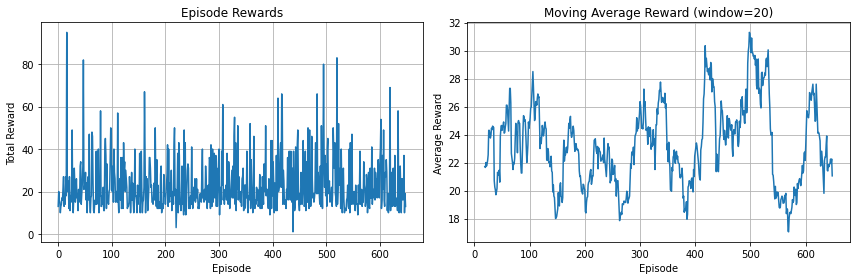

Final average reward (last 20 episodes): 21.05


In [18]:
# ## 5. Results and Visualization

# %%
# Plot training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(episode_rewards)
plt.title('Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)

plt.subplot(1, 2, 2)
# Plot moving average
window_size = 20
moving_avg = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
plt.plot(range(window_size-1, len(episode_rewards)), moving_avg)
plt.title(f'Moving Average Reward (window={window_size})')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final average reward (last 20 episodes): {np.mean(episode_rewards[-20:]):.2f}")


In [19]:
# ## 6. Test the Trained Agent

# %%
# Test the trained agent
def test_agent(agent, env, num_episodes=5):
    test_rewards = []
    
    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]
            
        total_reward = 0
        
        for step in range(500):
            action, _ = agent.get_action(state)
            state, reward, done, truncated, _ = env.step(action)
            if isinstance(state, tuple):
                state = state[0]
                
            total_reward += reward
            
            if done or truncated:
                break
        
        test_rewards.append(total_reward)
        print(f"Test Episode {episode + 1}: Reward = {total_reward}")
    
    return test_rewards

print("Testing trained agent:")
test_rewards = test_agent(agent, env)
print(f"Average test reward: {np.mean(test_rewards):.2f}")

# %%
env.close()
print("Environment closed. TRPO Hello World completed!")

Testing trained agent:
Test Episode 1: Reward = 41.0
Test Episode 2: Reward = 41.0
Test Episode 3: Reward = 33.0
Test Episode 4: Reward = 29.0
Test Episode 5: Reward = 25.0
Average test reward: 33.80
Environment closed. TRPO Hello World completed!
